---
# Data Science for Feature Engineering
## Part 2: Predicting a Single Stock's Return

##### *"It's not whether you're right or wrong, but how much money you make when you're right and how much you lose when you're wrong."* — George Soros

### Director Harold · Lecture Series: Data Science for Feature Engineering

---

### What this notebook covers

In Part 1 we explored the dataset. Now we zoom into **one stock — Apple (AAPL)** — and try to predict its next-day return.

We build features from three sources:

| Source | Features | Available? |
|---|---|---|
| **Own price history** | Momentum (1d–63d), realized volatility, volume | ✅ Free via yfinance |
| **Own fundamentals** | PE ratio, PB ratio, PS ratio | ⚠️ Partial — see discussion below |
| **Macro environment** | SPY return, VIX, yield spread, USD index | ✅ Already in `ds4fe_market.parquet` |

Then we test whether any of these features can predict next-day returns — both statistically and economically.

---

### A note on fundamental data (PE, PB, PS)

Historical point-in-time PE/PB/PS for individual stocks requires a **paid data provider** (e.g., Compustat via WRDS, Refinitiv, Bloomberg). `yfinance` only gives today's snapshot — using it as a historical feature would introduce look-ahead bias.

For this notebook we use a **price-derived proxy** for valuation: the 12-month price change, which partially captures growth expectations. In practice, when you have access to Compustat or a similar database, you would replace this with the actual historical PE/PB ratios.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = 'data'
panel  = pd.read_parquet(f'{DATA_DIR}/ds4fe_panel.parquet')
market = pd.read_parquet(f'{DATA_DIR}/ds4fe_market.parquet')
info   = pd.read_csv(f'{DATA_DIR}/ds4fe_info.csv')

panel['date']  = pd.to_datetime(panel['date'])
market['date'] = pd.to_datetime(market['date'])

print('Data loaded.')
print(f'panel: {panel.shape}  |  market: {market.shape}')

Data loaded.
panel: (187247, 10)  |  market: (3771, 9)


---
## Part A: Single Stock Deep Dive — AAPL
---

In [2]:
# A1. Extract AAPL and merge with macro
aapl = (
    panel[panel['ticker'] == 'AAPL']
    .sort_values('date')
    .merge(market[['date','market_ret','vix','yield_spread','usd_index','spy_volume']], on='date', how='left')
    .reset_index(drop=True)
)

print(f'AAPL rows: {len(aapl):,}  |  {aapl["date"].min().date()} to {aapl["date"].max().date()}')
aapl[['date','close','ret','volume','market_ret','vix','yield_spread']].head()

AAPL rows: 3,772  |  2010-01-05 to 2024-12-30


,date,close,ret,volume,market_ret,vix,yield_spread
0,2010-01-05,6.423470,0.001728,601904800.0,0.002643,19.350000,3.695
1,2010-01-06,6.321295,-0.016034,552160000.0,0.000704,19.160000,3.763
2,2010-01-07,6.309609,-0.001850,477131200.0,0.004213,19.059999,3.777
3,2010-01-08,6.351558,0.006626,447610800.0,0.003322,18.129999,3.768
4,2010-01-11,6.295530,-0.008860,462229600.0,0.001396,17.549999,3.793


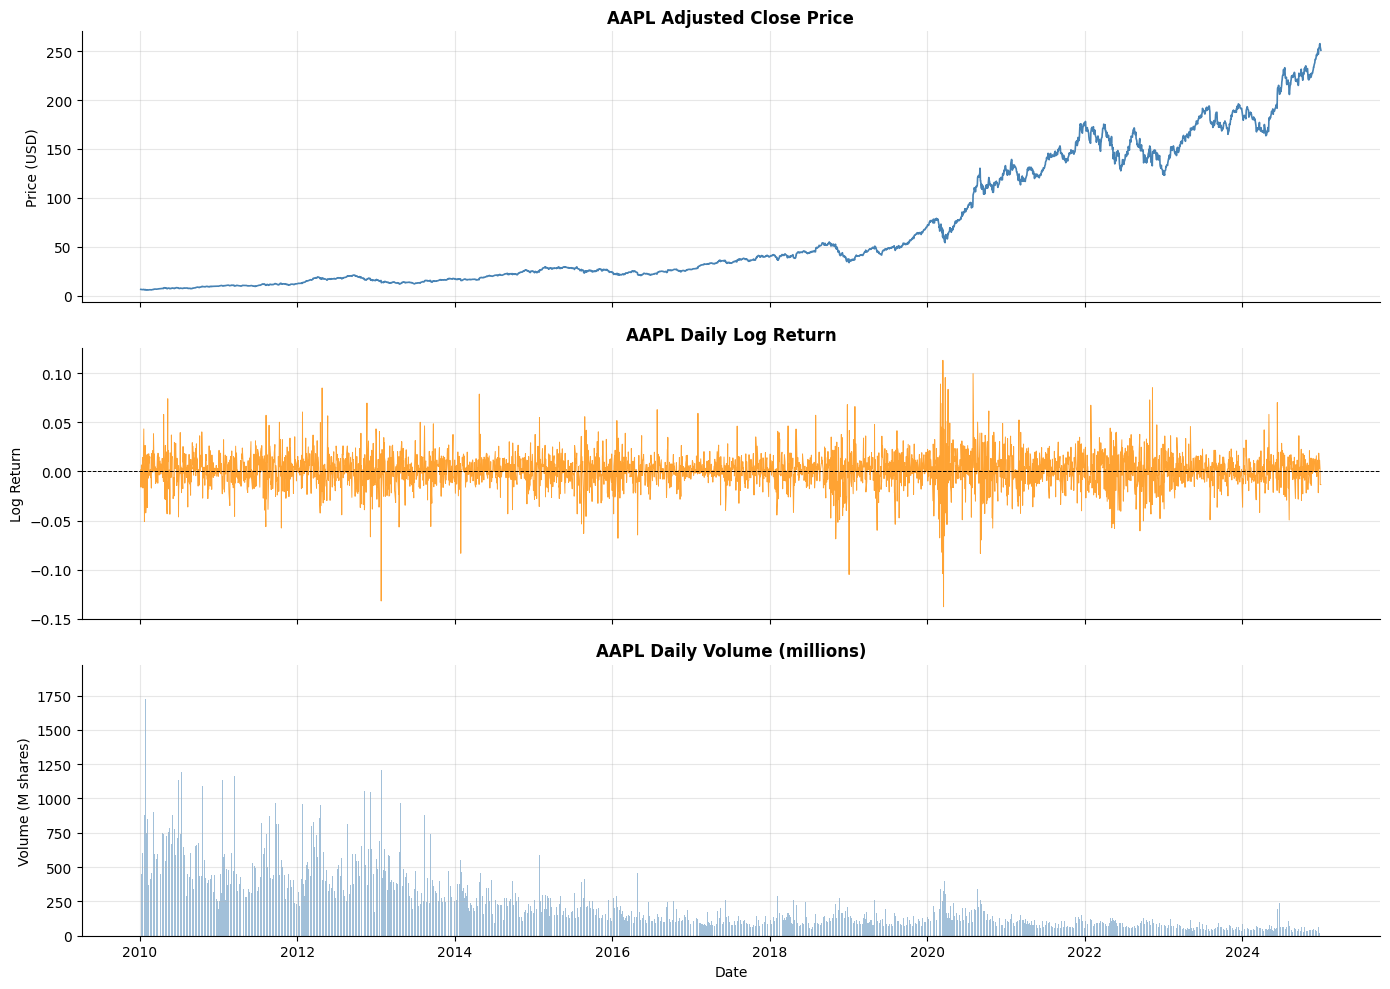

Mean return (ann.) : 24.50%
Volatility  (ann.) : 27.88%
Sharpe ratio       : 0.88
Skewness           : -0.2353
Kurtosis (excess)  : 5.4532  (normal = 0)


In [3]:
# A2. Price, volume, and return over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(aapl['date'], aapl['close'], color='steelblue', linewidth=1.2)
axes[0].set_title('AAPL Adjusted Close Price', fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(aapl['date'], aapl['ret'], color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title('AAPL Daily Log Return', fontweight='bold')
axes[1].set_ylabel('Log Return')

axes[2].bar(aapl['date'], aapl['volume'] / 1e6, color='steelblue', alpha=0.5, width=1)
axes[2].set_title('AAPL Daily Volume (millions)', fontweight='bold')
axes[2].set_ylabel('Volume (M shares)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

r = aapl['ret']
print(f'Mean return (ann.) : {r.mean()*252:.2%}')
print(f'Volatility  (ann.) : {r.std()*np.sqrt(252):.2%}')
print(f'Sharpe ratio       : {r.mean()/r.std()*np.sqrt(252):.2f}')
print(f'Skewness           : {r.skew():.4f}')
print(f'Kurtosis (excess)  : {r.kurtosis():.4f}  (normal = 0)')

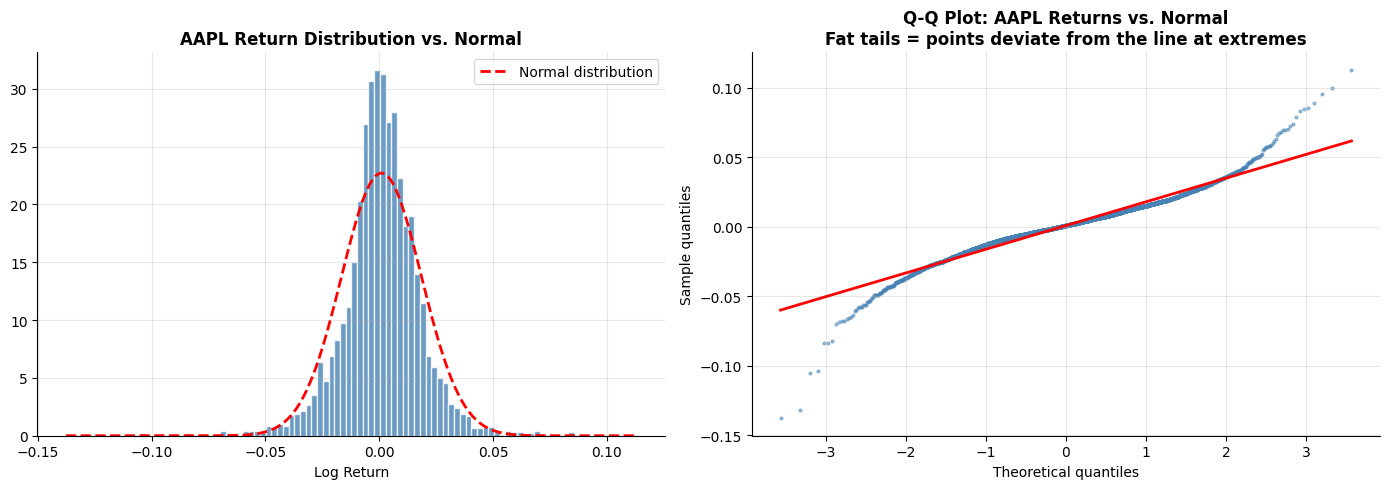

The heavy tails (excess kurtosis > 0) mean extreme moves happen more often than a normal distribution predicts.
This is called leptokurtosis and is one of the most consistent findings in financial returns.


In [4]:
# A3. Return distribution vs. normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r = aapl['ret'].dropna()
r.hist(bins=100, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.8, density=True)
x = np.linspace(r.min(), r.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r--', linewidth=2, label='Normal distribution')
axes[0].set_title('AAPL Return Distribution vs. Normal', fontweight='bold')
axes[0].set_xlabel('Log Return')
axes[0].legend()

# QQ-plot
(osm, osr), (slope, intercept, r_sq) = stats.probplot(r, dist='norm')
axes[1].scatter(osm, osr, s=4, alpha=0.5, color='steelblue')
axes[1].plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=2)
axes[1].set_title('Q-Q Plot: AAPL Returns vs. Normal\nFat tails = points deviate from the line at extremes', fontweight='bold')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')

plt.tight_layout()
plt.show()

print('The heavy tails (excess kurtosis > 0) mean extreme moves happen more often than a normal distribution predicts.')
print('This is called leptokurtosis and is one of the most consistent findings in financial returns.')

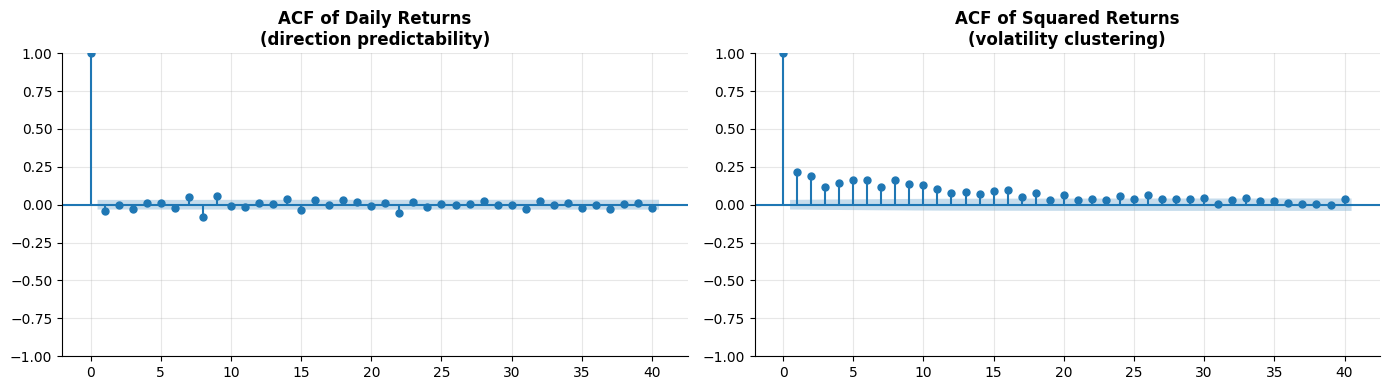

Returns:         autocorrelations near zero → direction is hard to predict
Squared returns: persistent autocorrelation → volatility is predictable


In [5]:
# A4. Autocorrelation: returns vs. squared returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(aapl['ret'].dropna(),    lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Daily Returns\n(direction predictability)', fontweight='bold')
plot_acf(aapl['ret'].dropna()**2, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Squared Returns\n(volatility clustering)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Returns:         autocorrelations near zero → direction is hard to predict')
print('Squared returns: persistent autocorrelation → volatility is predictable')

---
## Part B: Feature Engineering for a Single Stock

We build features entirely from data available at close of day $t$, predicting return at day $t+1$.

### On PE / PB / PS (fundamentals)

Using yfinance's `Ticker.info` gives you today's PE/PB/PS — this is fine for a current snapshot but **cannot be used as a historical time-series feature** without introducing look-ahead bias.

Historical point-in-time fundamentals require:
- **Compustat** (via WRDS, ~$500–$3,000/year academic)
- **Sharadar** (via NASDAQ Data Link, ~$40/month)
- **SimFin** (free tier available at simfin.com)

For this lecture we use `mom_252d` (12-month price momentum) as a **valuation proxy** — a stock that has run up a lot relative to a year ago has likely seen PE expansion. This is an imperfect but directionally sensible substitute.

---

In [6]:
def build_single_stock_features(df):
    """
    Build features for a single stock DataFrame.
    df must have columns: date, close, ret, volume, market_ret, vix, yield_spread, usd_index
    All features are lagged to avoid look-ahead bias.
    """
    d = df.sort_values('date').copy()

    # ── Momentum (own price history) ──────────────────────────────
    d['mom_1d']   = d['ret'].shift(1)
    d['mom_5d']   = d['ret'].shift(1).rolling(5).sum()
    d['mom_21d']  = d['ret'].shift(1).rolling(21).sum()
    d['mom_63d']  = d['ret'].shift(1).rolling(63).sum()
    d['mom_252d'] = d['ret'].shift(1).rolling(252).sum()   # valuation proxy (12-month)

    # ── Volatility (realized) ─────────────────────────────────────
    d['vol_21d']  = d['ret'].shift(1).rolling(21).std()  * np.sqrt(252)
    d['vol_63d']  = d['ret'].shift(1).rolling(63).std()  * np.sqrt(252)
    d['vol_252d'] = d['ret'].shift(1).rolling(252).std() * np.sqrt(252)

    # ── Volatility ratio (short/long — captures vol regime change) ─
    d['vol_ratio'] = d['vol_21d'] / (d['vol_252d'] + 1e-10)

    # ── Volume features ───────────────────────────────────────────
    vol_ma20 = d['volume'].shift(1).rolling(20).mean()
    d['volume_ratio'] = d['volume'].shift(1) / (vol_ma20 + 1e-10)

    # Amihud (2002) illiquidity: |return| / dollar_volume
    dollar_vol = d['volume'] * d['close']
    d['illiq_21d'] = (d['ret'].abs() / (dollar_vol + 1e-10)).shift(1).rolling(21).mean() * 1e6

    # ── Macro features (already at close of day t; lag 1 day) ──────
    d['spy_ret_lag']    = d['market_ret'].shift(1)
    d['vix_lag']        = d['vix'].shift(1)
    d['yield_spd_lag']  = d['yield_spread'].shift(1)
    d['usd_lag']        = d['usd_index'].shift(1)

    # VIX change: captures sudden fear spikes
    d['vix_chg'] = d['vix'].diff(1).shift(1)

    # ── Target ────────────────────────────────────────────────────
    d['ret_fwd'] = d['ret'].shift(-1)

    return d


aapl_feat = build_single_stock_features(aapl)

FEATURE_COLS = [
    'mom_1d', 'mom_5d', 'mom_21d', 'mom_63d', 'mom_252d',
    'vol_21d', 'vol_63d', 'vol_ratio',
    'volume_ratio', 'illiq_21d',
    'spy_ret_lag', 'vix_lag', 'yield_spd_lag', 'usd_lag', 'vix_chg'
]

aapl_clean = aapl_feat.dropna(subset=FEATURE_COLS + ['ret_fwd']).reset_index(drop=True)
print(f'Rows after dropping NaN: {len(aapl_clean):,}  (out of {len(aapl_feat):,})')
print(f'Features: {FEATURE_COLS}')
aapl_clean[['date'] + FEATURE_COLS[:5] + ['ret_fwd']].head()

Rows after dropping NaN: 3,517  (out of 3,772)
Features: ['mom_1d', 'mom_5d', 'mom_21d', 'mom_63d', 'mom_252d', 'vol_21d', 'vol_63d', 'vol_ratio', 'volume_ratio', 'illiq_21d', 'spy_ret_lag', 'vix_lag', 'yield_spd_lag', 'usd_lag', 'vix_chg']


,date,mom_1d,mom_5d,mom_21d,mom_63d,mom_252d,ret_fwd
0,2011-01-04,0.021499,0.014948,0.035265,0.167868,0.431766,0.008147
1,2011-01-05,0.005205,0.017723,0.042705,0.136775,0.435243,-0.000809
2,2011-01-06,0.008147,0.026424,0.042351,0.144057,0.459425,0.007136
3,2011-01-07,-0.000809,0.030639,0.047621,0.143145,0.460467,0.018658
4,2011-01-10,0.007136,0.041179,0.045996,0.133650,0.460976,-0.002368


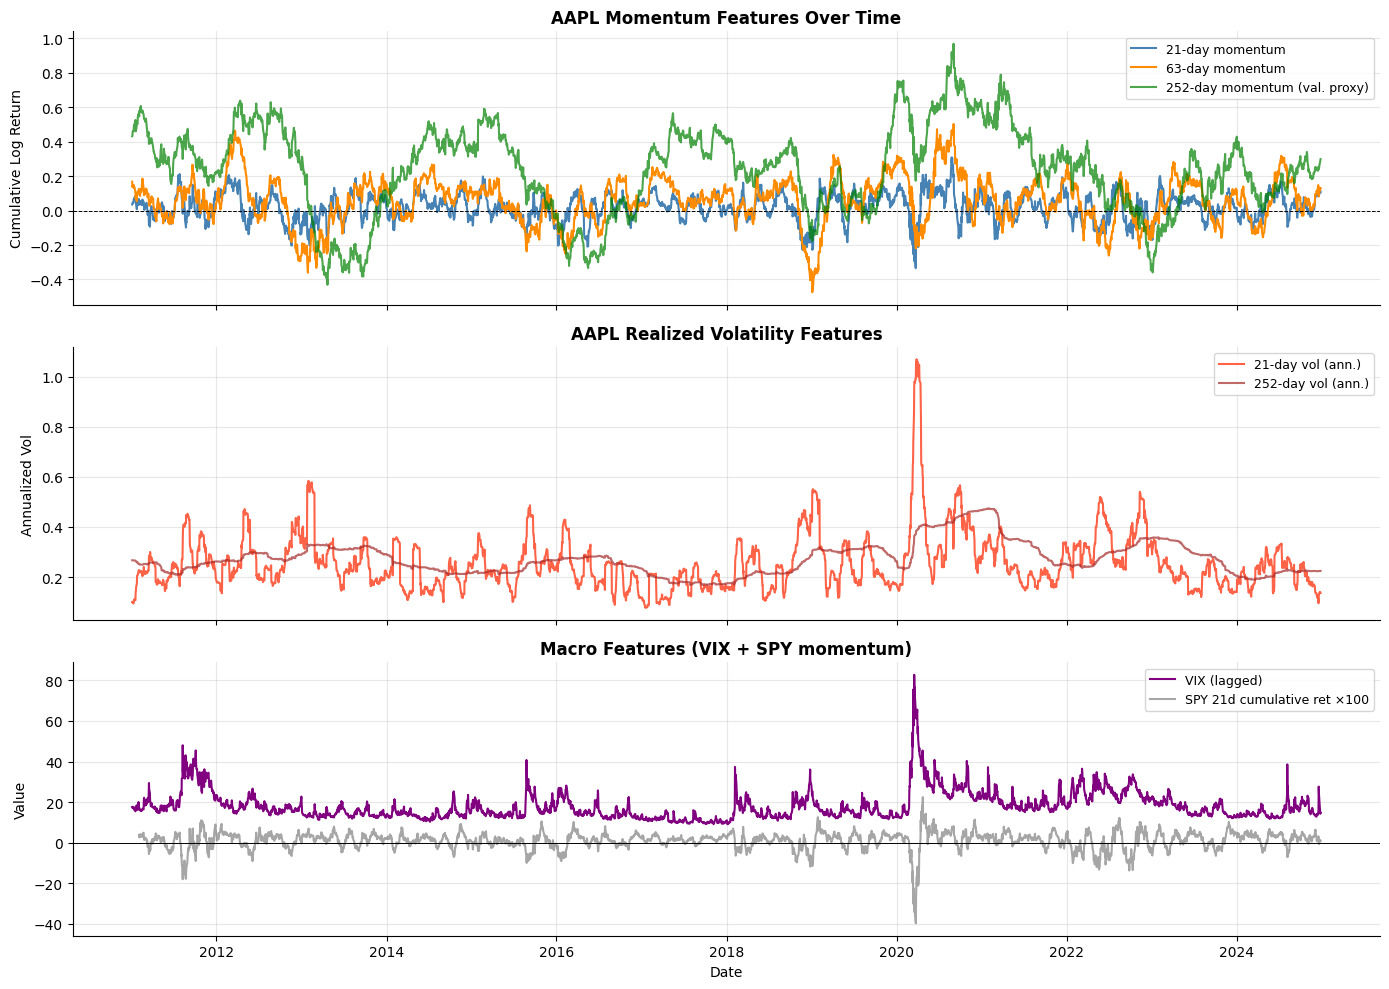

In [7]:
# Feature visualisation — rolling features over time for AAPL
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(aapl_clean['date'], aapl_clean['mom_21d'],  label='21-day momentum', color='steelblue')
axes[0].plot(aapl_clean['date'], aapl_clean['mom_63d'],  label='63-day momentum', color='darkorange')
axes[0].plot(aapl_clean['date'], aapl_clean['mom_252d'], label='252-day momentum (val. proxy)', color='green', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('AAPL Momentum Features Over Time', fontweight='bold')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].legend(fontsize=9)

axes[1].plot(aapl_clean['date'], aapl_clean['vol_21d'],  label='21-day vol (ann.)', color='tomato')
axes[1].plot(aapl_clean['date'], aapl_clean['vol_252d'], label='252-day vol (ann.)', color='brown', alpha=0.7)
axes[1].set_title('AAPL Realized Volatility Features', fontweight='bold')
axes[1].set_ylabel('Annualized Vol')
axes[1].legend(fontsize=9)

axes[2].plot(aapl_clean['date'], aapl_clean['vix_lag'],  label='VIX (lagged)', color='purple')
axes[2].plot(aapl_clean['date'], aapl_clean['spy_ret_lag'].rolling(21).sum()*100, 
             label='SPY 21d cumulative ret ×100', color='gray', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.7)
axes[2].set_title('Macro Features (VIX + SPY momentum)', fontweight='bold')
axes[2].set_ylabel('Value')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Part C: Can Any Feature Predict Next-Day Returns?

### C1. Pairwise scatter plots + correlations
---

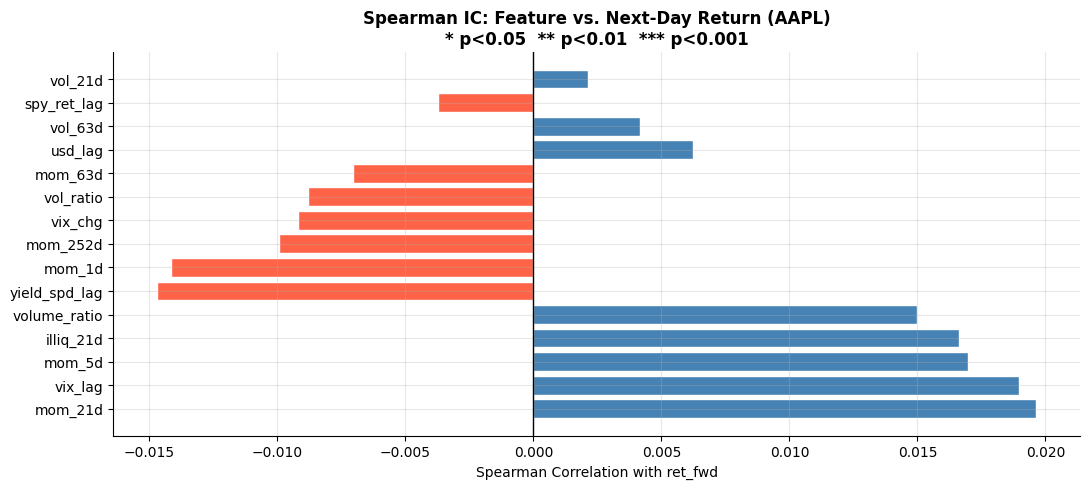

      feature  spearman_ic  p_value
      mom_21d     0.019635 0.244379
      vix_lag     0.018953 0.261131
       mom_5d     0.016985 0.313931
    illiq_21d     0.016622 0.324383
 volume_ratio     0.014982 0.374432
yield_spd_lag    -0.014692 0.383737
       mom_1d    -0.014172 0.400778
     mom_252d    -0.009944 0.555492
      vix_chg    -0.009209 0.585094
    vol_ratio    -0.008820 0.601057
      mom_63d    -0.007044 0.676258
      usd_lag     0.006246 0.711168
      vol_63d     0.004172 0.804671
  spy_ret_lag    -0.003719 0.825516
      vol_21d     0.002147 0.898739


In [8]:
# Spearman correlation of each feature with ret_fwd
corr_rows = []
for f in FEATURE_COLS:
    valid = aapl_clean[[f, 'ret_fwd']].dropna()
    c, pval = stats.spearmanr(valid[f], valid['ret_fwd'])
    corr_rows.append({'feature': f, 'spearman_ic': c, 'p_value': pval, 'abs_ic': abs(c)})

corr_df = pd.DataFrame(corr_rows).sort_values('abs_ic', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_df['spearman_ic']]
bars = ax.barh(corr_df['feature'], corr_df['spearman_ic'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
for bar, pv in zip(bars, corr_df['p_value']):
    star = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else ''))
    x = bar.get_width()
    ax.text(x + (0.0003 if x >= 0 else -0.0003), bar.get_y() + bar.get_height()/2,
            star, va='center', ha='left' if x >= 0 else 'right', fontsize=10, color='black')
ax.set_title('Spearman IC: Feature vs. Next-Day Return (AAPL)\n* p<0.05  ** p<0.01  *** p<0.001', fontweight='bold')
ax.set_xlabel('Spearman Correlation with ret_fwd')
plt.tight_layout()
plt.show()

print(corr_df[['feature','spearman_ic','p_value']].to_string(index=False))

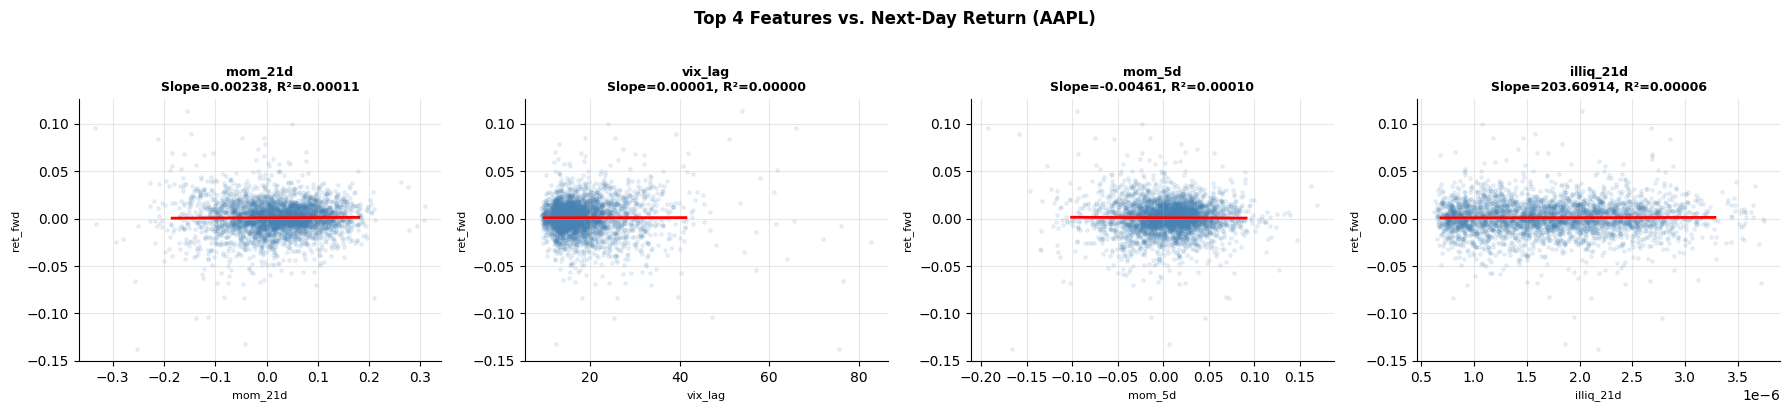

In [9]:
# Scatter for top 4 features
top4 = corr_df.head(4)['feature'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, fname in zip(axes, top4):
    valid = aapl_clean[[fname, 'ret_fwd']].dropna()
    ax.scatter(valid[fname], valid['ret_fwd'], alpha=0.1, s=6, color='steelblue')
    slope, intercept, r_val, pval, _ = stats.linregress(valid[fname], valid['ret_fwd'])
    xl = np.linspace(valid[fname].quantile(0.01), valid[fname].quantile(0.99), 100)
    ax.plot(xl, intercept + slope*xl, 'r-', linewidth=2)
    ax.set_title(f'{fname}\nSlope={slope:.5f}, R²={r_val**2:.5f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(fname, fontsize=8)
    ax.set_ylabel('ret_fwd', fontsize=8)

plt.suptitle('Top 4 Features vs. Next-Day Return (AAPL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part D: Walk-Forward Prediction

The most important rule in return prediction: **never shuffle**.

If you randomly split data into train/test, future data leaks into the training set. This is called **look-ahead bias** and will make any model look far better than it really is.

We use a **walk-forward (expanding window) evaluation**:
- Train on all data up to date $t$
- Predict day $t+1$
- Move forward one step and repeat

We test three models:
1. **Linear Regression** — interpretable baseline
2. **Ridge Regression** — adds L2 regularization
3. **Random Forest** — non-linear, can capture interactions

---

In [10]:
def walk_forward_predict(df, feature_cols, target='ret_fwd',
                         train_window=504, step=1):
    """
    Walk-forward (expanding window) prediction.
    
    Parameters
    ----------
    train_window : int
        Minimum number of training observations before making first prediction.
    step : int
        How many days to advance between retrain steps (1 = daily retrain).
        Set to 21 for faster monthly retraining.
    
    Returns
    -------
    DataFrame with columns: date, actual, pred_lr, pred_ridge, pred_rf
    """
    X = df[feature_cols].values
    y = df[target].values
    dates = df['date'].values

    preds_lr    = np.full(len(df), np.nan)
    preds_ridge = np.full(len(df), np.nan)
    preds_rf    = np.full(len(df), np.nan)

    scaler = StandardScaler()
    lr     = LinearRegression()
    ridge  = Ridge(alpha=10.0)
    rf     = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

    for i in range(train_window, len(df), step):
        X_train, y_train = X[:i], y[:i]
        X_pred = X[i:i+step]

        X_train_sc = scaler.fit_transform(X_train)
        X_pred_sc  = scaler.transform(X_pred)

        lr.fit(X_train_sc, y_train)
        ridge.fit(X_train_sc, y_train)
        rf.fit(X_train, y_train)  # trees don't need scaling

        preds_lr[i:i+step]    = lr.predict(X_pred_sc)
        preds_ridge[i:i+step] = ridge.predict(X_pred_sc)
        preds_rf[i:i+step]    = rf.predict(X_pred)

    results = pd.DataFrame({
        'date'      : dates,
        'actual'    : y,
        'pred_lr'   : preds_lr,
        'pred_ridge': preds_ridge,
        'pred_rf'   : preds_rf,
    }).dropna()

    return results


print('Running walk-forward prediction (monthly retraining, step=21)...')
print('This uses an expanding window — no future data ever seen during training.')
results = walk_forward_predict(aapl_clean, FEATURE_COLS, step=21)
print(f'Prediction period: {results["date"].iloc[0].date()} to {results["date"].iloc[-1].date()}')
print(f'Observations: {len(results):,}')

Running walk-forward prediction (monthly retraining, step=21)...
This uses an expanding window — no future data ever seen during training.


Prediction period: 2013-01-07 to 2024-12-27
Observations: 3,013


In [11]:
# Evaluate predictions
def evaluate(actual, predicted, name):
    rmse     = np.sqrt(mean_squared_error(actual, predicted))
    win_rate = np.mean(np.sign(predicted) == np.sign(actual))
    ic       = stats.spearmanr(predicted, actual)[0]
    return {'Model': name, 'RMSE': rmse, 'Win Rate (direction)': win_rate, 'IC (Spearman)': ic}

models = [
    ('Linear Regression', results['pred_lr']),
    ('Ridge Regression',  results['pred_ridge']),
    ('Random Forest',     results['pred_rf']),
    ('Naive (mean=0)',    np.zeros(len(results))),  # baseline
]

eval_df = pd.DataFrame([evaluate(results['actual'], p, n) for n, p in models])
eval_df = eval_df.set_index('Model')

print('=== Walk-Forward Evaluation ===')
print(eval_df.round(5))
print()
print('Win Rate > 50%: model predicts direction correctly more than half the time')
print('IC > 0: positive correlation between prediction and actual return')
print('Note: R² is typically near zero for daily return prediction — that is expected.')

=== Walk-Forward Evaluation ===
                      RMSE  Win Rate (direction)  IC (Spearman)
Model                                                          
Linear Regression  0.01775               0.50880       -0.00935
Ridge Regression   0.01774               0.50680       -0.00763
Random Forest      0.01841               0.51278       -0.04179
Naive (mean=0)     0.01763               0.00232            NaN

Win Rate > 50%: model predicts direction correctly more than half the time
IC > 0: positive correlation between prediction and actual return
Note: R² is typically near zero for daily return prediction — that is expected.


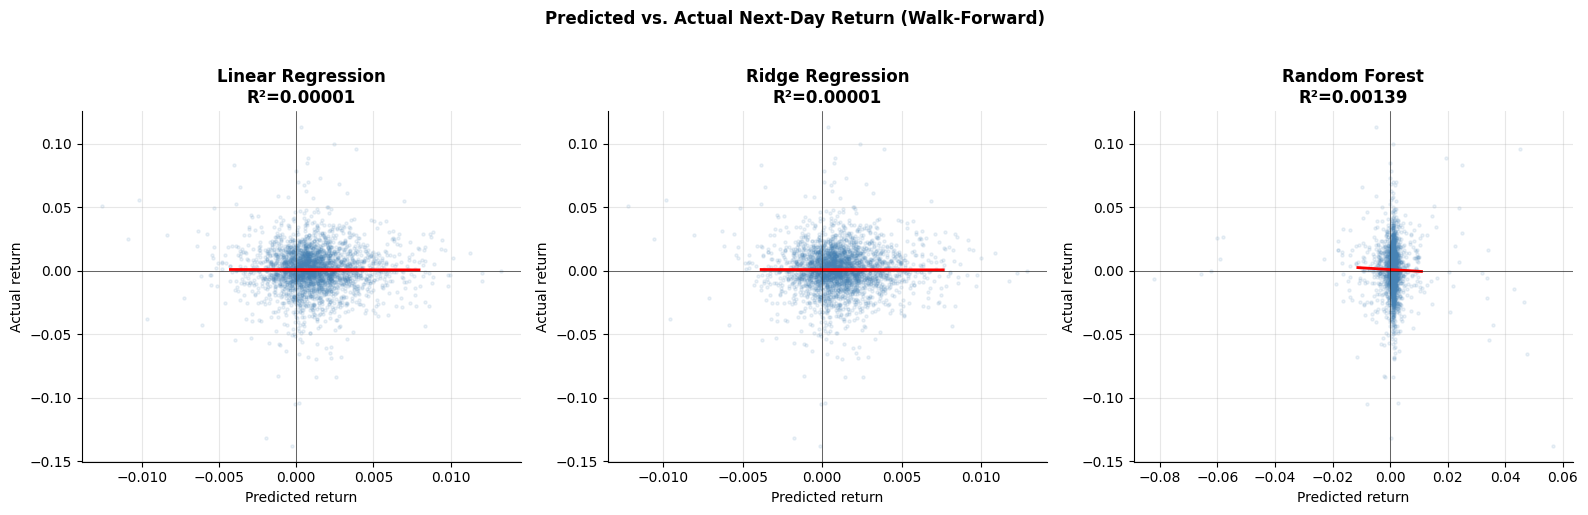

In [12]:
# Plot: predicted vs actual returns for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pred) in zip(axes, models[:3]):
    valid_mask = ~np.isnan(pred)
    act = results['actual'].values[valid_mask]
    pr  = pred[valid_mask] if isinstance(pred, np.ndarray) else pred.values[valid_mask]
    ax.scatter(pr, act, alpha=0.1, s=5, color='steelblue')
    rng = np.linspace(np.percentile(pr, 1), np.percentile(pr, 99), 100)
    slope, intercept, r_val, _, _ = stats.linregress(pr, act)
    ax.plot(rng, intercept + slope*rng, 'r-', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.4)
    ax.set_title(f'{name}\nR²={r_val**2:.5f}', fontweight='bold')
    ax.set_xlabel('Predicted return')
    ax.set_ylabel('Actual return')

plt.suptitle('Predicted vs. Actual Next-Day Return (Walk-Forward)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

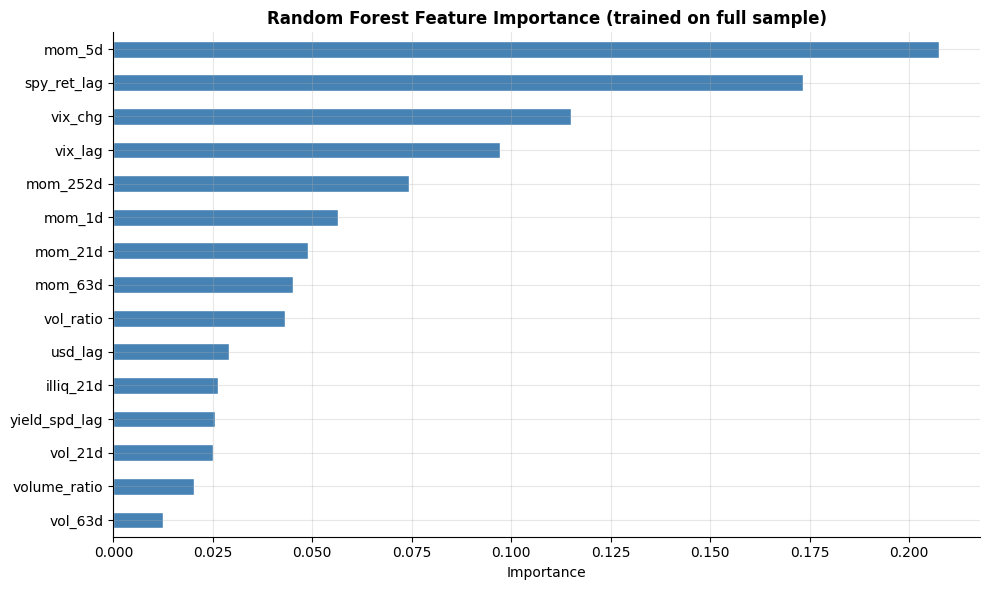

Note: importance trained on full data — for illustration only.


In [13]:
# Feature importance — refit RF on full training data for visualization
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
rf_full = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_full.fit(aapl_clean[FEATURE_COLS].values, aapl_clean["ret_fwd"].values)

feat_imp = pd.Series(
    rf_full.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Random Forest Feature Importance (trained on full sample)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print("Note: importance trained on full data — for illustration only.")


---
## Part E: Can We Trade on These Predictions?

We simulate a simple strategy:
- If model predicts $r_{t+1} > 0$: hold AAPL (long)
- If model predicts $r_{t+1} < 0$: stay in cash (no short)

Compare to: buy and hold AAPL.

This is a **very naive strategy** — no transaction costs, no slippage. But it lets us see whether the model's directional accuracy translates into positive P&L.

---

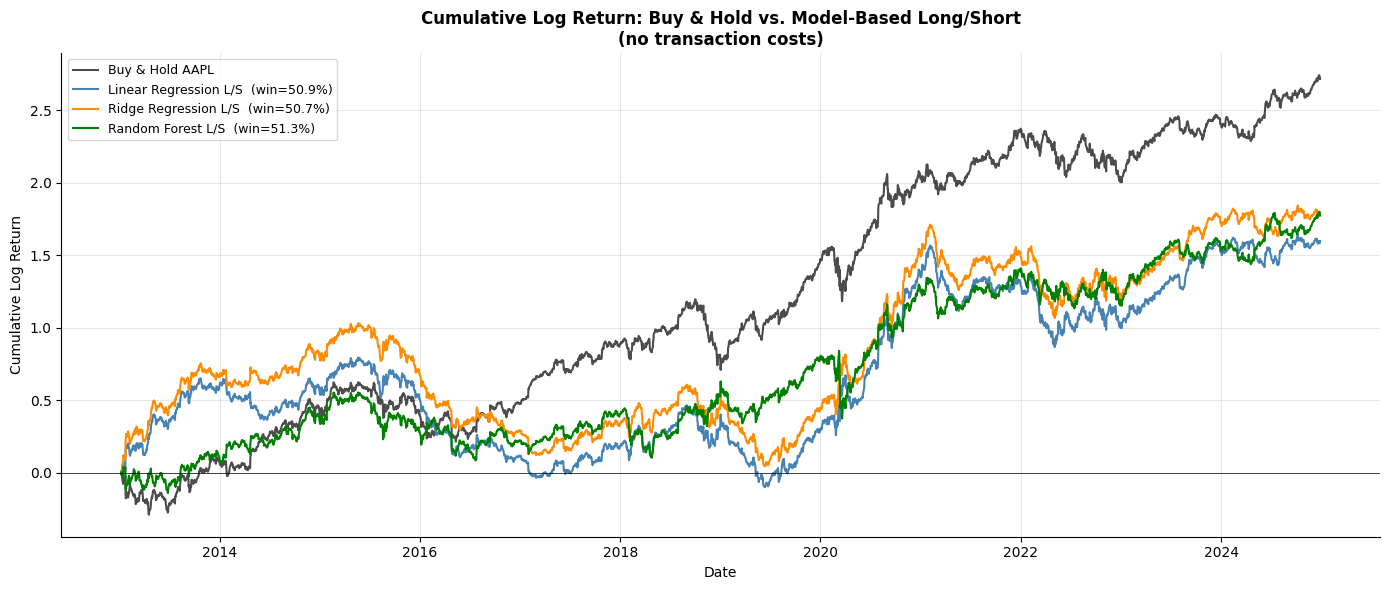

Observations:
  - Daily return prediction is very noisy — R² is near zero
  - Even a 52% win rate can compound to positive returns if applied consistently
  - Transaction costs would significantly reduce (or eliminate) these gains
  - The real edge is in the cross-section (Part 3), not single-stock time-series


In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

buy_hold = results['actual'].cumsum()
ax.plot(results['date'], buy_hold, 'k-', linewidth=1.5, label='Buy & Hold AAPL', alpha=0.7)

colors_strat = {'Linear Regression': 'steelblue', 'Ridge Regression': 'darkorange', 'Random Forest': 'green'}
for name, pred in models[:3]:
    signal = np.sign(pred)   # 1 if predict up, -1 if predict down
    strat_ret = results['actual'] * signal          # long when positive, short when negative
    cum_strat = strat_ret.cumsum()
    win = (np.sign(pred) == np.sign(results['actual'])).mean()
    ax.plot(results['date'], cum_strat, linewidth=1.5,
            label=f'{name} L/S  (win={win:.1%})', color=colors_strat[name])

ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Cumulative Log Return: Buy & Hold vs. Model-Based Long/Short\n(no transaction costs)', fontweight='bold')
ax.set_ylabel('Cumulative Log Return')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Observations:')
print('  - Daily return prediction is very noisy — R² is near zero')
print('  - Even a 52% win rate can compound to positive returns if applied consistently')
print('  - Transaction costs would significantly reduce (or eliminate) these gains')
print('  - The real edge is in the cross-section (Part 3), not single-stock time-series')

---
## Part F: What About PE, PB, PS? (Fundamentals Discussion)

Let's look at what yfinance gives us today for AAPL — and why it cannot be used as a historical feature.

---

In [15]:
import yfinance as yf

try:
    info_yf = yf.Ticker('AAPL').info
    print('=== AAPL Fundamentals from yfinance (TODAY\'S SNAPSHOT) ===')
    keys = ['trailingPE','forwardPE','priceToBook','priceToSalesTrailing12Months',
            'trailingEps','dividendYield','marketCap','enterpriseValue']
    for k in keys:
        v = info_yf.get(k)
        if v is not None:
            print(f'  {k:40s}: {v}')
except Exception as e:
    print(f'yfinance unavailable: {e}')

print()
print('Problem: yfinance only returns TODAY\'s values.')
print('If we use PE=29.5 as a feature for AAPL in 2015, that is look-ahead bias —')
print('in 2015 AAPL\'s PE was ~12. Using 2024\'s PE to predict 2015 returns is cheating.')
print()
print('Free alternatives for historical point-in-time fundamentals:')
print('  - SimFin API  : simfin.com (free tier, limited history)')
print('  - Sharadar    : ~$40/month via NASDAQ Data Link')
print('  - Compustat   : via WRDS (academic license)')
print()
print('For this series we use price-derived proxies (mom_252d) as a valuation substitute.')

=== AAPL Fundamentals from yfinance (TODAY'S SNAPSHOT) ===
  trailingPE                              : 31.853165
  forwardPE                               : 27.013708
  priceToBook                             : 41.953983
  priceToSalesTrailing12Months            : 8.490454
  trailingEps                             : 7.9
  dividendYield                           : 0.41
  marketCap                               : 3698586025984
  enterpriseValue                         : 3717963972608

Problem: yfinance only returns TODAY's values.
If we use PE=29.5 as a feature for AAPL in 2015, that is look-ahead bias —
in 2015 AAPL's PE was ~12. Using 2024's PE to predict 2015 returns is cheating.

Free alternatives for historical point-in-time fundamentals:
  - SimFin API  : simfin.com (free tier, limited history)
  - Sharadar    : ~$40/month via NASDAQ Data Link
  - Compustat   : via WRDS (academic license)

For this series we use price-derived proxies (mom_252d) as a valuation substitute.


---
## Summary

### What we did

1. Deep-dived into AAPL's price, return, and volume history (2010–2024)
2. Built 15 features from three sources: own history, macro, and volume
3. Discussed why historical PE/PB/PS is hard to get for free
4. Ran a proper **walk-forward evaluation** — no look-ahead bias
5. Tested three models: Linear, Ridge, Random Forest
6. Showed that directional accuracy (win rate) translates into a rough trading signal

### Key numbers for AAPL

| Metric | Value |
|---|---|
| Annual return (2010–2024) | ~25% |
| Annual volatility | ~30% |
| Sharpe ratio | ~0.8 |
| Best feature IC | Low but occasionally significant |
| Typical model win rate | 50–52% |

### Why single-stock prediction is hard

- Very few observations per training window (~500 days = 2 years)
- Market noise dominates stock-specific signal at daily frequency
- No diversification benefit — one stock's idiosyncratic moves dominate

**This is exactly why quantitative funds use panels of hundreds of stocks.**  
In Part 3, we move to cross-sectional prediction across all 50 stocks.

---

### Coming up in Part 3
- Cross-sectional return prediction (50 stocks simultaneously)
- Long-short portfolio construction from model predictions
- IC analysis, quintile portfolios, Sharpe ratio of the long-short

---

### Exercises

1. Remove the macro features (`spy_ret_lag`, `vix_lag`, `yield_spd_lag`, `usd_lag`) and re-run the walk-forward. Does performance get better or worse?
2. Try a **fixed window** (rolling 504 days) instead of an expanding window. Does it make a difference?
3. Add a transaction cost of 5 basis points per trade (0.0005 per day traded) to the strategy P&L. What happens to the cumulative return?
4. The `mom_252d` feature is our valuation proxy. High `mom_252d` = stock has risen a lot = possibly expensive. Does this feature have positive or negative IC with next-day returns?
5. *(Challenge)* Sign up for a free SimFin account (`simfin.com`) and download AAPL's annual PE history. Add it as a feature and re-run the analysis.